# Chapter 0: Data Audit and Exploratory Analysis

Before any inferential analysis, this chapter verifies the integrity of the 
raw dataset, checking structure, data types, and the presence of missing 
or anomalous values. Furthermore, it provides a first visual mapping of the main 
variables and their relationships.

In [1]:
import pandas as pd
#load the dataset
df=pd.read_csv("../data/human_performance_dataset.csv")
#print variables
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 975425 entries, 0 to 975424
Data columns (total 19 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   step                         975425 non-null  int64  
 1   trajectory_id                975425 non-null  int64  
 2   regime                       975425 non-null  object 
 3   reaction_time                975425 non-null  float64
 4   error_rate                   975425 non-null  float64
 5   motivation                   975425 non-null  float64
 6   timestamp                    975425 non-null  object 
 7   task_type                    975425 non-null  object 
 8   task_difficulty              975425 non-null  float64
 9   time_pressure                975425 non-null  object 
 10  error_severity               975425 non-null  object 
 11  downstream_cost              975425 non-null  int64  
 12  risk_score                   975425 non-null  float64
 13 

### 0.1 Structural Integrity
The dataset contains 975,425 observations across 19 variables, with 
zero missing values across the board. No imputation is required. 
Let's inspect the first rows to confirm the data looks as expected.

In [2]:
df.head()

,step,trajectory_id,regime,reaction_time,error_rate,motivation,timestamp,task_type,task_difficulty,time_pressure,error_severity,downstream_cost,risk_score,skill_baseline,fatigue_sensitivity,resilience_factor,mission_failure_probability,expected_loss,intervention_effectiveness
0,0,0,NORMAL,409.990811,0.064074,8.271224,2023-07-25 14:58:53.016006783,monitoring,0.418229,low,minor,0,25.361594,0.676819,0.984083,0.765658,0.078432,0.000000,0.518212
1,1,0,NORMAL,604.333789,0.063963,6.984834,2023-07-25 15:09:08.920586166,monitoring,0.369670,low,minor,0,23.882631,0.676819,0.984083,0.765658,0.068387,0.000000,0.518212
2,2,0,NORMAL,549.450027,0.064438,6.230788,2023-07-25 15:19:56.821859704,monitoring,0.527565,low,minor,0,28.714490,0.676819,0.984083,0.765658,0.106353,0.000000,0.518212
3,3,0,NORMAL,479.728081,0.065361,5.936007,2023-07-25 15:29:20.158798225,reaction,0.718383,low,minor,50,34.623683,0.676819,0.984083,0.765658,0.176880,8.843991,0.518212
4,4,0,NORMAL,565.509924,0.064799,4.890426,2023-07-25 15:40:21.260736285,analysis,0.833457,low,minor,50,37.963558,0.676819,0.984083,0.765658,0.230828,11.541379,0.518212


Now let's look at the descriptive statistics to check the plausible range 
of each numeric variable and spot any values that fall outside expected 
bounds (e.g. negative reaction times, out-of-range probabilities).

In [3]:
df.describe()

,step,trajectory_id,reaction_time,error_rate,motivation,task_difficulty,downstream_cost,risk_score,skill_baseline,fatigue_sensitivity,resilience_factor,mission_failure_probability,expected_loss,intervention_effectiveness
count,975425.000000,975425.000000,975425.000000,975425.000000,975425.000000,975425.000000,975425.000000,975425.000000,975425.000000,975425.000000,975425.000000,975425.000000,975425.000000,975425.000000
mean,3507.044684,69.419534,430.135907,0.048379,6.241226,0.624852,169.410360,32.654896,0.797878,0.988867,0.996125,0.196350,83.696074,0.795493
std,2022.034080,40.442515,286.877214,0.034272,2.900157,0.163074,686.605003,11.939030,0.115782,0.272178,0.177148,0.184344,569.945606,0.187617
min,0.000000,0.000000,149.995311,0.005000,0.000000,0.300155,0.000000,10.174011,0.606576,0.509173,0.701202,0.018296,0.000000,0.452627
25%,1755.000000,34.000000,194.307161,0.019523,4.293430,0.490316,0.000000,24.012607,0.690144,0.767747,0.832539,0.069220,0.000000,0.639159
50%,3513.000000,69.000000,364.568313,0.041124,6.898804,0.625581,50.000000,30.917434,0.776644,0.997550,0.986883,0.129177,6.209724,0.768642
75%,5259.000000,104.000000,568.840590,0.069206,8.556507,0.751441,100.000000,39.556048,0.901992,1.189122,1.158550,0.260303,16.847039,0.903717
max,7000.000000,139.000000,3000.002002,0.352274,10.004401,1.000000,25000.000000,99.735398,0.999579,1.488588,1.296246,0.993129,24777.624867,1.275052


No anomalies were detected.

### 0.2 Distribution and Relationship Mapping
With the structure confirmed, we move to visualizing individual 
distributions and screening for correlations between variables.

We start with `reaction_time`, since its distribution shape (normal vs. 
skewed) will determine which statistical tests are valid in Chapter 4.

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean graphic style
sns.set_theme(style="whitegrid")

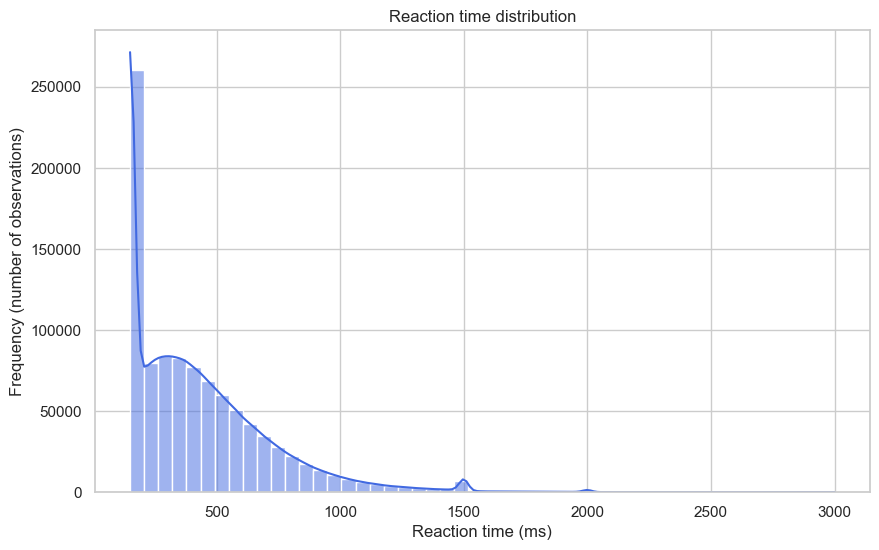

In [5]:
# Set figure size
plt.figure(figsize=(10, 6))

# Create boxplot about time pressure
sns.histplot(df['reaction_time'], bins=50, color='royalblue', kde=True)

# Add title and axis labels
plt.title('Reaction time distribution')
plt.xlabel('Reaction time (ms)')
plt.ylabel('Frequency (number of observations)')

# Display the plot
plt.show()

Observation: The reaction time distribution is heavily right-skewed with a peak frequency exceeding 250,000 observations near 200 ms, showing a rapid concentration at lower values, a gradual tapering into a long tail extending up to 3000 ms, and small secondary outlier peaks around 1500 ms and 2000 ms

Next, we check the balance of the `regime` variable (NORMAL, STRESSED, 
BURNOUT), since an uneven sample across groups would affect the 
reliability of later between-group comparisons.

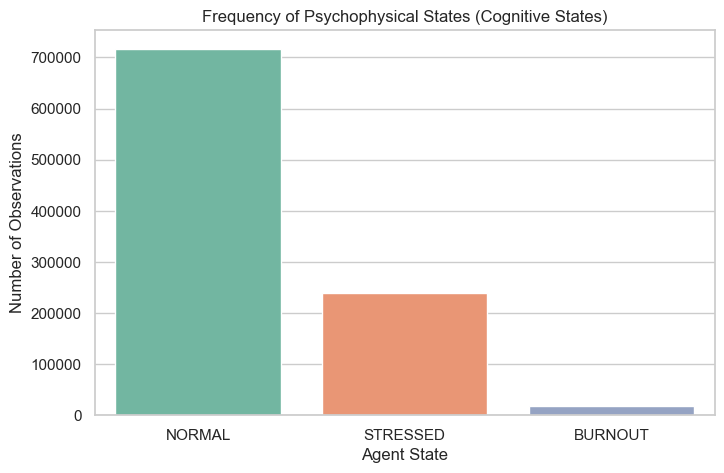

In [6]:
# Set figure size
plt.figure(figsize=(8, 5))

# Create a bar plot for the regime column
sns.countplot(data=df, x='regime', hue='regime', palette='Set2', legend=False)

# Add title and axis labels
plt.title("Frequency of Psychophysical States (Cognitive States)")
plt.xlabel("Agent State")
plt.ylabel("Number of Observations")

# Display the plot
plt.show()

Observation: The psychophysical states are heavily imbalanced, with 'NORMAL' dominating the sample at over 700,000 observations, followed by 'STRESSED' at around 240,000, and 'BURNOUT' remaining extremely scarce.

### 0.3 Correlation Screening
Finally, a correlation matrix across all numeric variables helps rule out 
multicollinearity issues and identifies the strongest linear relationships 
worth investigating further in the following chapters.

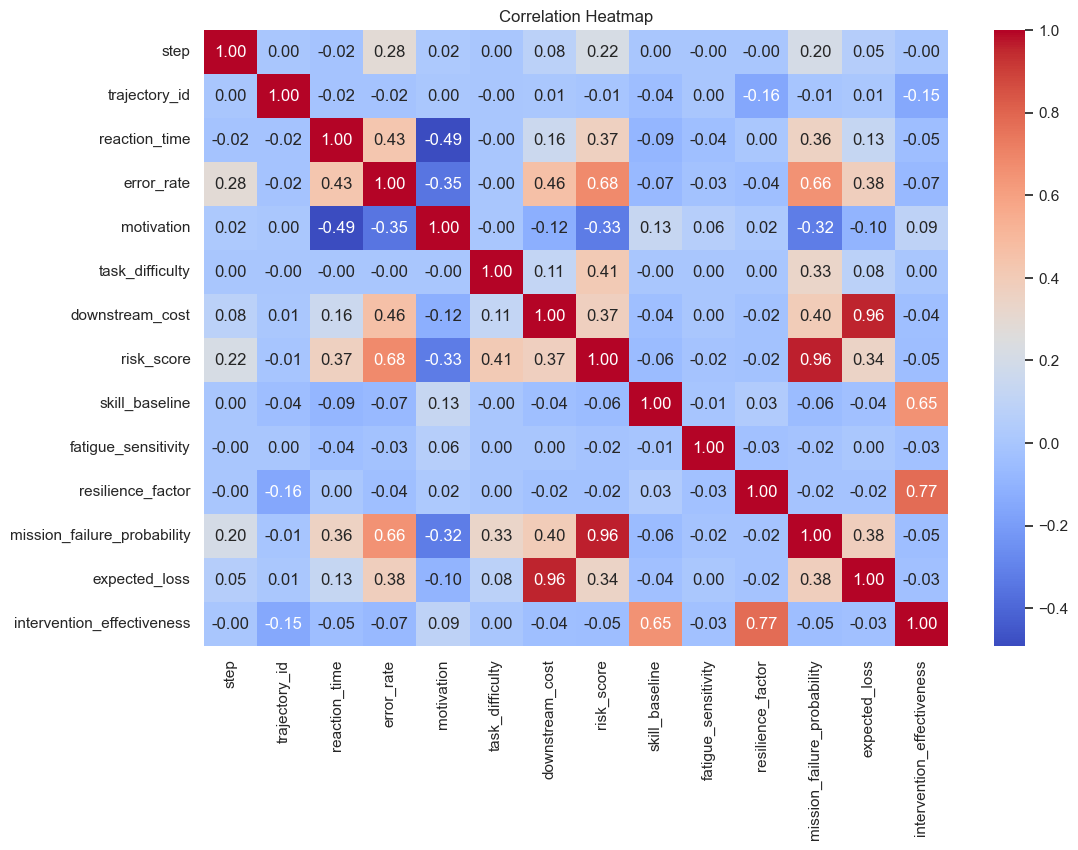

In [7]:
# Set a figure size large enough to accommodate all variables
plt.figure(figsize=(12, 8))

# Calculate the correlation matrix
correlation_matrix = df.corr(numeric_only=True)

# Plot the heatmap
sns.heatmap(correlation_matrix, cmap="coolwarm", annot=True, fmt=".2f")

# Add title and display the plot
plt.title("Correlation Heatmap")
plt.show()

### Chapter 0 Conclusions
The dataset is clean and well-structured, requiring no cleaning steps.